In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

Load training Data


In [2]:
train_data = pd.read_csv("../data/train.csv")

Preparing features and Target

In [3]:
customer_features = train_data.drop(columns=["id", "Churn"])

churn_target = train_data["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [4]:
numeric_features = customer_features.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = customer_features.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric features:", numeric_features)
print("\nCategorical features:", categorical_features)

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


Split


In [5]:
X_train, X_valid, y_train, y_valid = train_test_split(
    customer_features,
    churn_target,
    test_size=0.20,
    random_state=31,
    stratify=churn_target
)

Random Forest Preprocessing

In [6]:
rf_preprocessor = ColumnTransformer(
    transformers=[
        ("numbers", "passthrough", numeric_features),
        (
            "categories",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

Random Forest Model

In [7]:
random_forest_model = RandomForestClassifier(
    n_estimators=120,
    max_depth=18,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=31,
    n_jobs=-1
)

Pipeline

In [8]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessing", rf_preprocessor),
        ("classifier", random_forest_model)
    ]
)

Training the Model

In [9]:
random_forest_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numbers', 'passthrough',
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('categories',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 RandomForestClassifier(max_depth=18, min_samples_leaf=5,
                                        n_estimators=120, n_jobs=-1,
                                        random_state=31))])

Validation Prediction

In [10]:
rf_predictions = random_forest_pipeline.predict(X_valid)

rf_probabilities = random_forest_pipeline.predict_proba(
    X_valid
)[:, 1]

In [11]:
print("Class predictions:", len(rf_predictions))
print("Probability predictions:", len(rf_probabilities))
print("Validation rows:", len(X_valid))

Class predictions: 118839
Probability predictions: 118839
Validation rows: 118839


Random Forest results

In [12]:
rf_results = {
    "Accuracy": accuracy_score(y_valid, rf_predictions),
    "Precision": precision_score(y_valid, rf_predictions),
    "Recall": recall_score(y_valid, rf_predictions),
    "F1-score": f1_score(y_valid, rf_predictions),
    "ROC-AUC": roc_auc_score(y_valid, rf_probabilities)
}

for metric, value in rf_results.items():
    print(f"{metric}: {value:.4f}")

Accuracy: 0.8577
Precision: 0.7002
Recall: 0.6435
F1-score: 0.6707
ROC-AUC: 0.9123


Classification Report

In [13]:
print(
    classification_report(
        y_valid,
        rf_predictions,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.90      0.92      0.91     92076
       Churn       0.70      0.64      0.67     26763

    accuracy                           0.86    118839
   macro avg       0.80      0.78      0.79    118839
weighted avg       0.85      0.86      0.86    118839



Confusion Matrix

In [14]:
rf_confusion_matrix = confusion_matrix(
    y_valid,
    rf_predictions
)

print(rf_confusion_matrix)

[[84700  7376]
 [ 9540 17223]]


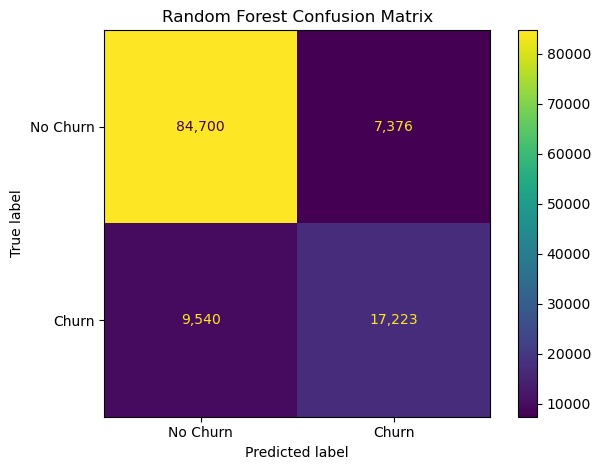

In [15]:
ConfusionMatrixDisplay.from_predictions(
    y_valid,
    rf_predictions,
    display_labels=["No Churn", "Churn"],
    values_format=","
)

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.savefig(
    "../screenshots/random_forest_confusion_matrix.png",
    dpi=150
)
plt.show()

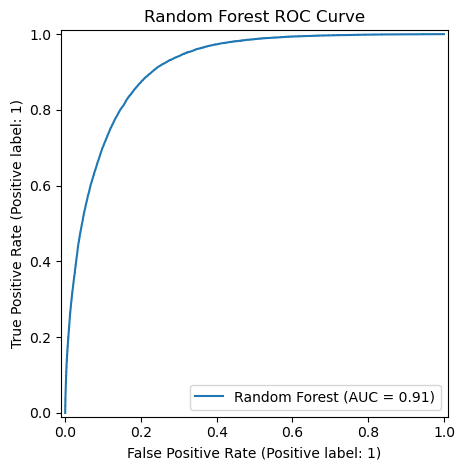

In [16]:
RocCurveDisplay.from_predictions(
    y_valid,
    rf_probabilities,
    name="Random Forest"
)

plt.title("Random Forest ROC Curve")
plt.tight_layout()
plt.savefig(
    "../screenshots/random_forest_roc_curve.png",
    dpi=150
)
plt.show()

In [17]:
model_comparison = pd.DataFrame(
    [
        {
            "Accuracy": 0.8546,
            "Precision": 0.6845,
            "Recall": 0.6576,
            "F1-score": 0.6708,
            "ROC-AUC": 0.9082
        },
        {
            "Accuracy": 0.8075,
            "Precision": 0.5447,
            "Recall": 0.8835,
            "F1-score": 0.6739,
            "ROC-AUC": 0.9081
        },
        rf_results
    ],
    index=[
        "Logistic Regression",
        "Weighted Logistic Regression",
        "Random Forest"
    ]
)

model_comparison.round(4)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Logistic Regression,0.8546,0.6845,0.6576,0.6708,0.9082
Weighted Logistic Regression,0.8075,0.5447,0.8835,0.6739,0.9081
Random Forest,0.8577,0.7002,0.6435,0.6707,0.9123
